# Residence time calculations:
To investigate the feeding performance of spiral vs non-spiral echinoderms, non-dimensional residence time $t^*$ was calculated at a range of points close to the organism's surface and over the last ten timesteps. The distribution of $t^*$ is plotted to compare how long particles spend near to the ambulacra.

Non-dimensional residence time:
$t* = \frac{|\mathcal{H}| D}{U_0^2}$
where $\mathcal{H}$ is helicity, $D$ is the length/diameter of the region in question and $U_0$ is the free stream velocity.

In [1]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import csv
import gc
import seaborn as sns
import scipy
import scipy.stats as stats 

# importing parameters and functions
import parameters as par
import functions as func


### Edrioasteroids
Last 10 seconds of sim. Square of cells at slice z = L + 0.1 L (=0.033m), to cover region just above ambulacral surface, with D roughly equal to 0.03, the width of the top surface

In [ ]:
kailidiscus_t = func.calc_residence_time(par.Kailidiscus.name, 'helicity.csv', D = 0.03, U_0 = 0.1)
stromatocystites_t = func.calc_residence_time(par.Stromatocystites.name, 'helicity.csv', 0.03, 0.1)
edrio_data = {'Kailidiscus': np.abs(kailidiscus_t), 'Stromatocystites': np.abs(stromatocystites_t)}
print(edrio_data)


{'Kailidiscus': array([4.1316e-03, 6.3654e-04, 9.6588e-12, ..., 6.2040e-04, 6.1233e-04,
       6.4380e-05], shape=(77950,)), 'Stromatocystites': array([3.18450e-04, 3.08310e-04, 5.54640e-06, ..., 3.49500e-05,
       1.45116e-05, 5.54250e-03], shape=(72880,))}


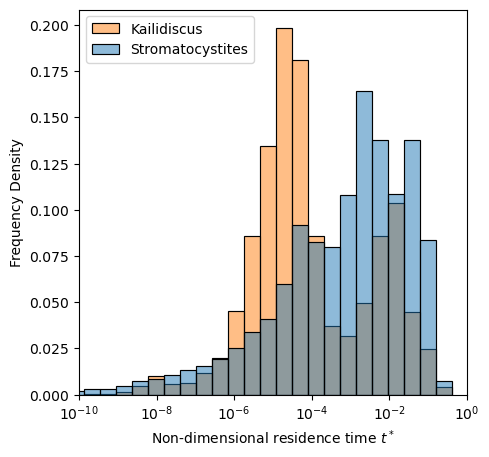

In [3]:
# Source - https://stackoverflow.com/a/75945045
# Posted by Trenton McKinney
# Retrieved 2026-03-05, License - CC BY-SA 4.0

fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(data=edrio_data,
            stat='density',
            #common_norm=True, 
            #multiple='stack', 
            bins=30, 
            ax=ax,
            log_scale=True,
            #kde=True
            )
#ax.set_yscale('log')
ax.set_xlabel('Non-dimensional residence time 'r'$t^*$')
ax.set_ylabel('Frequency Density')
#ax.set_ylim(0, 1)
ax.set_xlim(1e-10,1)




ax.legend(edrio_data, loc='upper left')
plt.savefig('figures/non_dim_res_time_edrios.pdf', dpi=300, bbox_inches='tight')


The non-dimensional residence time is lower in the spiral Kailidiscus so we could say that feeding performance way lower than in Stromatocystites

### Helicocystis:
Diameter of top surface = 0.003 so taking data in wake on x-normal surface at $x = D + 0.1D = 0.0033$ m.

In [8]:
def calc_residence_time(taxon, file, D, U_0): 
    # Reads in helicity data from paraview, calculates returns non-dimensional residence time t*
    dir = '../' + taxon +'/velocity/v0.1/postProcessing/'
    with open(dir + file) as f:
        #row_count = sum(1 for row in f)
        H = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            H.append(float(row['avg(Helicity)']))  # Access by column header instead of column number

        H = np.array(H)
        residence_time = H*D/U_0
        #residence_velocity = D/residence_time
        return residence_time

In [37]:
helicocystis_straight_t_new = calc_residence_time("helicocystis_straight", 'helicity_average.csv', 0.0033, 0.1)
helicocystis_t_new = calc_residence_time("helicocystis", 'helicity_average.csv', 0.0033, 0.1)

print(helicocystis_t_new)
helico_data_new = {'Helicocystis': helicocystis_t_new, 'Helicocystis (Straight)': helicocystis_straight_t_new}

[0.01560867 0.0159852  0.01208394 0.01339668 0.01622907 0.01288155
 0.01875423 0.01553211 0.00978285 0.01666071 0.01819191 0.01187769
 0.01424412 0.01524204 0.0136884  0.01425006 0.01267794 0.0131142
 0.01610334 0.0130218  0.01086888]


In [ ]:
helicocystis_t = func.calc_residence_time(par.Helicocystis.name, 'helicity.csv', 0.0033, 0.1)
helicocystis_straight_t = func.calc_residence_time(par.Helicocystis_straight.name, 'helicity.csv', 0.0033, 0.1)
helico_data = {'Helicocystis': np.abs(helicocystis_t), 'Helicocystis (Straight)': np.abs(helicocystis_straight_t)}


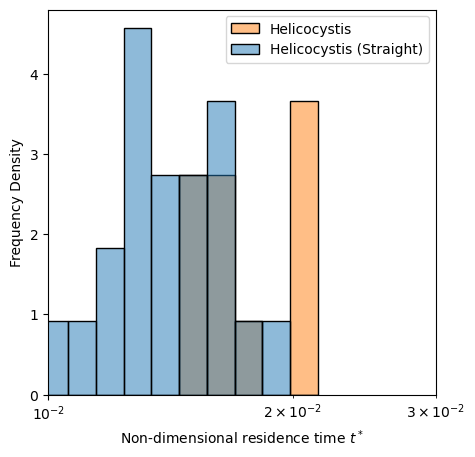

In [39]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(data=helico_data_new,
            stat='density',
            #common_norm=True, 
            #multiple='stack', 
            bins=10, 
            ax=ax,
            log_scale=True
            #kde=True
            )
#ax.set_yscale('log')
ax.set_xlabel('Non-dimensional residence time 'r'$t^*$')
ax.set_ylabel('Frequency Density')
ax.set_xlim(1e-2,3e-2)


ax.legend(helico_data)
plt.savefig('figures/non_dim_res_time_helicos.pdf', dpi=300, bbox_inches='tight')


### Gogiids
Measured helicity at earea inside brachioles
Gogia spiralis: z-norm plane at z = 0.04, D=0.016
Gogia palmeri: z-norm plane at z = 0.08, D = 0.026

In [7]:
gogia_spiralis_t = func.calc_residence_time(par.Gogia_spiralis.name, 'helicity.csv', D = 0.016, U_0 = 0.1)
gogia_palmeri = func.calc_residence_time(par.Gogia_palmeri.name, 'helicity.csv', D = 0.026, U_0 = 0.1)
gogiid_data = {'Gogia spiralis': np.abs(gogia_spiralis_t), 'Gogia palmeri': np.abs(gogia_palmeri)}

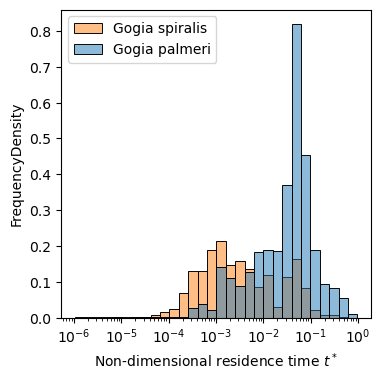

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(data=gogiid_data,
            stat='density',
            common_norm=True, 
            #multiple='stack', 
            bins=30, 
            ax=ax,
            log_scale=True,
            #kde=True
            )
#ax.set_yscale('log')
ax.set_xlabel('Non-dimensional residence time 'r'$t^*$')
ax.set_ylabel('FrequencyDensity')



ax.legend(gogiid_data)
plt.savefig('figures/non_dim_res_time_gogiids.pdf', dpi=300, bbox_inches='tight')


### Combined plot:

/tmp/jmcdermo_10485712/ipykernel_4144965/3221483109.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[0].set_ylim(0, 1e2)


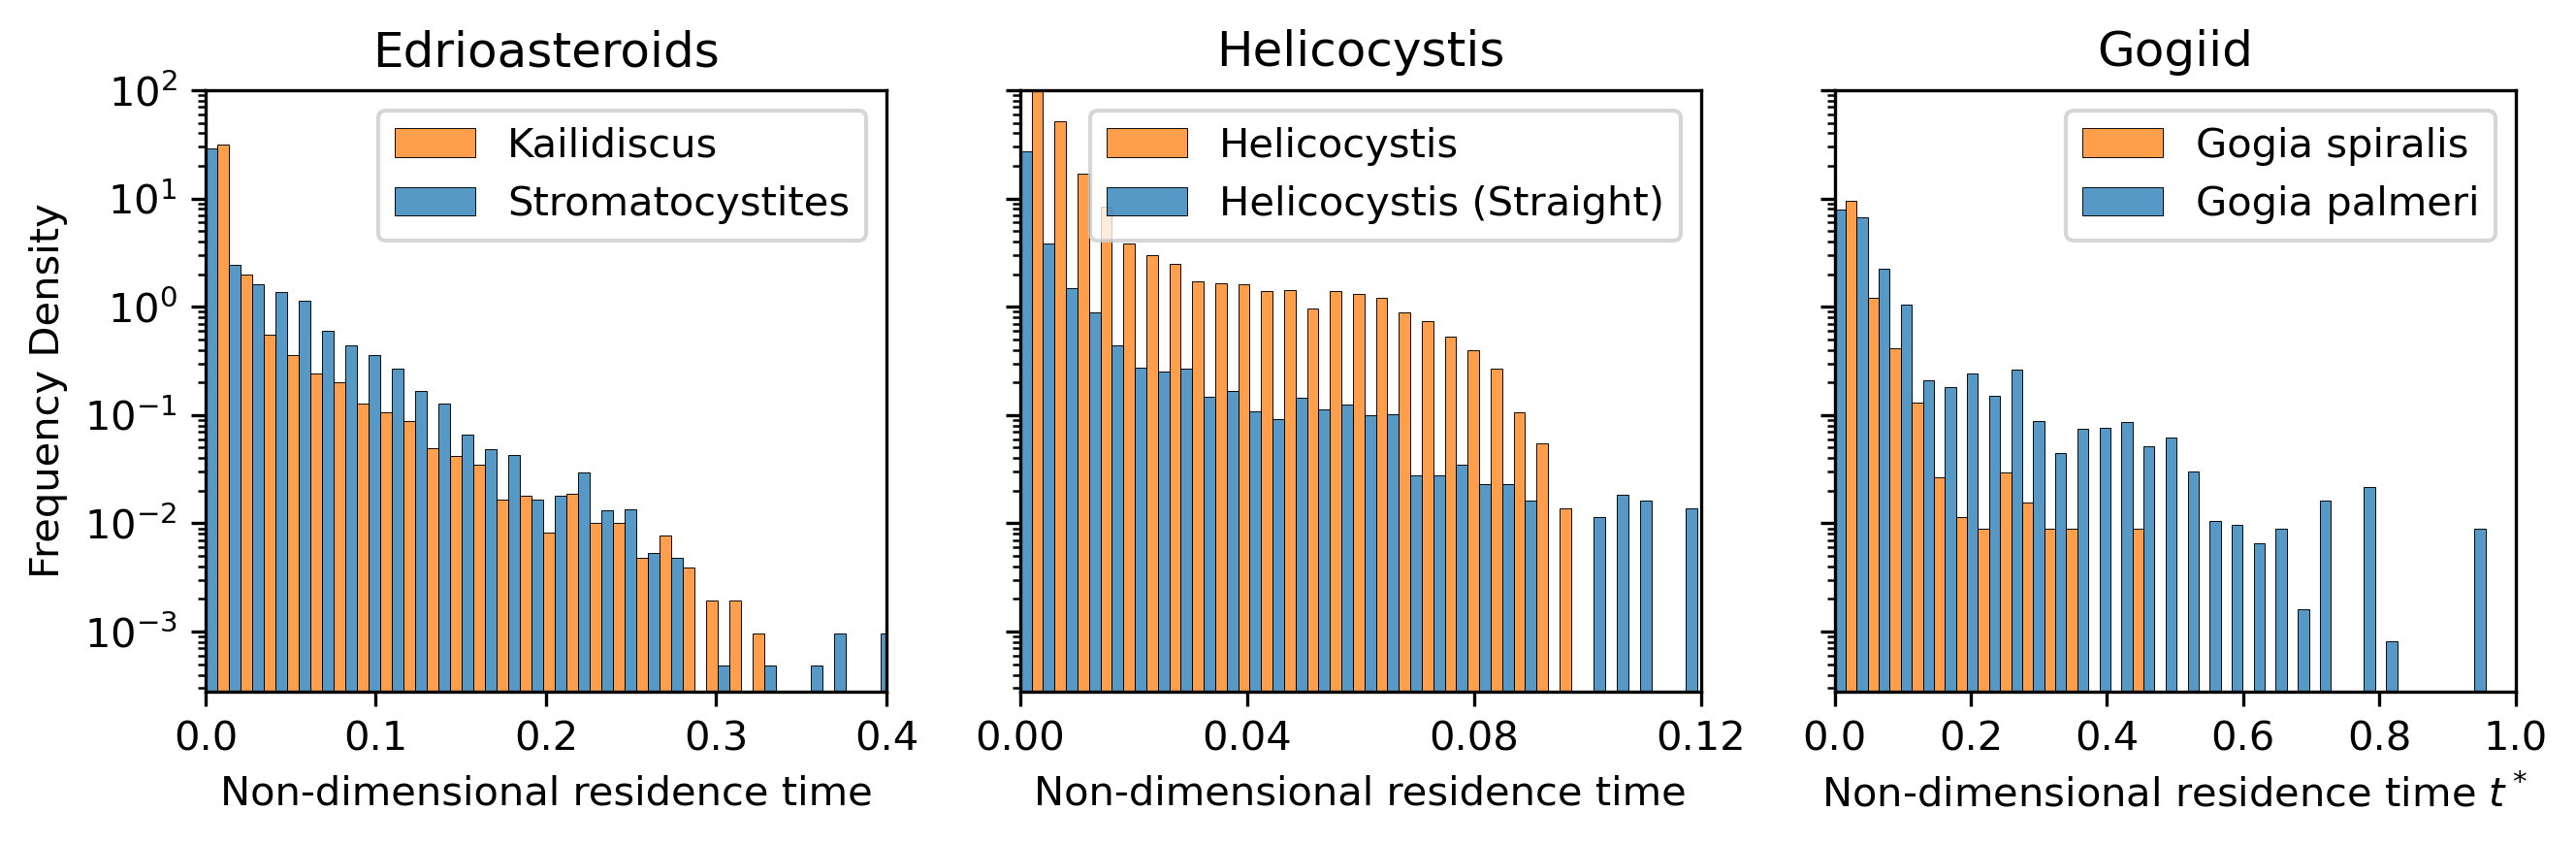

In [28]:
fig, axs = plt.subplots(1,3,figsize=(9, 3), sharey=True, dpi = 300)
sns.histplot(data=edrio_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[0],
            )
axs[0].set_yscale('log')
axs[0].set_xlabel('Non-dimensional residence time')
axs[0].set_ylabel('Frequency Density')
axs[0].legend(edrio_data)
axs[0].set_title('Edrioasteroids')
axs[0].set_ylim(0, 1e2)
axs[0].set_xlim(0, 0.4)


sns.histplot(data=helico_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[1],
            )
axs[1].set_yscale('log')
axs[1].set_xlabel('Non-dimensional residence time')
axs[1].set_ylabel('Frequency Density')
axs[1].legend(helico_data)
axs[1].set_title('Helicocystis')
axs[1].set_xticks([0, 0.04, 0.08, 0.12])
axs[1].set_xlim(0, 0.12)

sns.histplot(data=gogiid_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[2],
            )
axs[2].set_yscale('log')
axs[2].set_xlabel('Non-dimensional residence time 'r'$t^*$')
axs[2].set_ylabel('Frequency Density')
axs[2].legend(gogiid_data)
axs[2].set_title('Gogiid')
axs[2].set_xlim(0, 1)

plt.tight_layout()
#plt.savefig('residence_time.pdf', dpi=300, bbox_inches='tight')